In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA, SparsePCA, KernelPCA
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler

In [2]:
#importing the data
df = pd.read_excel("../Data/COVID19_proteomics.xlsx")
df.head(20)

# run PCA with 4 components
pca_res = PCA(n_components=4) #running PCA with 4 components, we can choose the number of components based on the number of dimensions we want to visualise or based on the proportion of variance explained by the components
pca_transform = pca_res.fit_transform(df.iloc[:, 3:])
print(pca_transform.shape)
print(type(pca_transform))

(382, 4)
<class 'numpy.ndarray'>


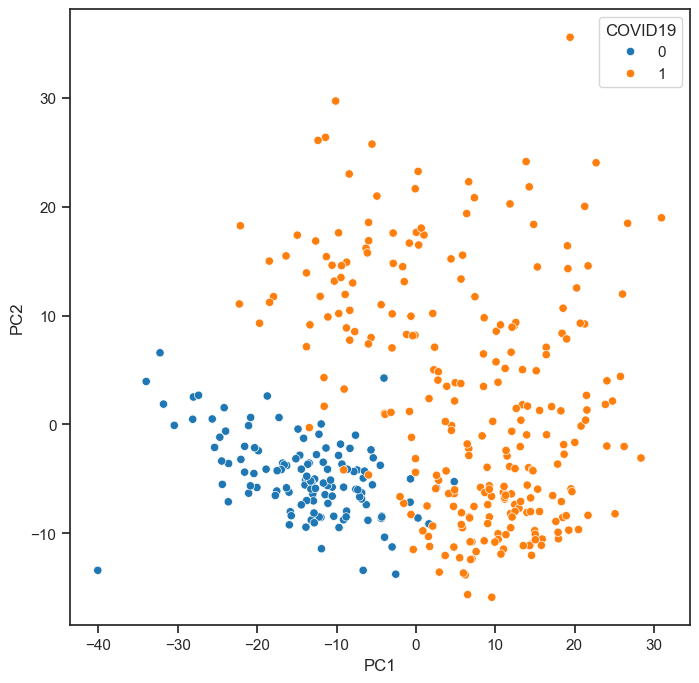

In [4]:
# Scatterplot
sns.set_style("ticks")
sns.set_context("notebook")
plt.figure(figsize=(8, 8))
p = sns.scatterplot(x=pca_transform[:, 0], y=pca_transform[:, 1], hue=df.iloc[:, 0])
p.set_xlabel("PC1")
p.set_ylabel("PC2")

plt.show()

In [ ]:
#Store PCA result in pca_df dataframe 
pca_df = pd.DataFrame(pca_transform, columns=["PC"+str(i) for i in range(1, pca_transform.shape[1]+1)])
pca_df["status"] = df.iloc[:,0]

pca_df


KeyError: 1

In [ ]:
# Pairplot 
sns.pairplot(data=pca_df, hue="status")
plt.show()
sns.set_style("ticks")
sns.set_context("notebook")
plt.figure(figsize=(8, 8))
p = sns.scatterplot(x=pca_transform[:, 0], y=pca_transform[:, 1], hue=df.iloc[:,0])

# Label pairplot % variance explained
pvars = pca_res.explained_variance_ratio_[:2] * 100

p.set_xlabel(("PC1: " "{:.2f}%".format(pvars[0])))
p.set_ylabel(("PC2: " "{:.2f}%".format(pvars[1])))

plt.show()

In [ ]:
# Scree plot
# PCA with 20 components
pca_df = PCA(n_components=20)
pca_df.fit(df.iloc[:, 3:])

# use the attribute .explained_variance_ratio_ to get the eigenvalues
variance_per_component = pca_df.explained_variance_ratio_

# sum the eigenvalues to get the cumulative variance explained for each component
cumulative_variance = np.cumsum(variance_per_component)
components = list(range(1, 21))

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
sns.barplot(x=components, y=variance_per_component, palette="viridis", ax=ax, hue=components)


In [ ]:
# show the cumulative variance with a blue line
sns.pointplot(x=components, y=cumulative_variance, ax=ax, color="blue", label="Cumulative variance")

plt.xlabel("Components")
plt.ylabel("Eigenvalue (% variance explained)")
plt.show()

In [ ]:
# extracting the scores and loadings (transposing the latter in the process) of the first 2 components (note: this can be different in other datasets)
scores = pca_df.transform(df.iloc[:, 3:])
loadings = pca_df.components_[:2].T
features = list(df.columns[3:])

loadingVector = loadings * np.abs(scores[:, :2]).max(axis=0)

sns.set_style("ticks")
sns.set_context("notebook")
plt.figure(figsize=(8, 8))

p = sns.scatterplot(x=scores[:, 0], y=scores[:, 1], hue=df["COVID19"])

p.set_xlabel(("PC1: " "{:.2f}%".format(pvars[0])))
p.set_ylabel(("PC2: " "{:.2f}%".format(pvars[1])))

# features as arrows
for i, arrow in enumerate(loadingVector):
    plt.arrow(0, 0, *arrow, color='k', alpha=0.5, width=0.1, ec='none', length_includes_head=True)
    #plt.text(*(arrow * 1.05), features[i], ha='center', va='center') # this is commented, see what happens when you uncomment
plt.figure(figsize=(12, 8))

lp = sns.lineplot(data=loadings, palette="rocket")

lp.set_xlabel("Feature")
lp.set_ylabel("Loading weights")
lp.set_xticks(range(len(features)), labels=features, rotation=90)

plt.show()

In [ ]:
plt.figure(figsize=(12, 8))

lp = sns.lineplot(data=loadings, palette="rocket")

lp.set_xlabel("Feature")
lp.set_ylabel("Loading weights")
lp.set_xticks(range(len(features)), labels=features, rotation=90)

plt.show()

loading_vector = loadings[:,0]*loadings[:,1]
n = 20
ind = loading_vector.argsort()[:n]
features = np.array(features)
top_features = features[ind]
top_features
loadingVector_n = loadingVector[ind,:]

sns.set_style("ticks")
sns.set_context("notebook")
plt.figure(figsize=(8, 8))

p = sns.scatterplot(x=scores[:, 0], y=scores[:, 1], hue=df["COVID19"])

p.set_xlabel(("PC1: " "{:.2f}%".format(pvars[0])))
p.set_ylabel(("PC2: " "{:.2f}%".format(pvars[1])))

# features as arrows
for i, arrow in enumerate(loadingVector_n):
    plt.arrow(0, 0, *arrow, color='k', alpha=0.5, width=0.1, ec='none', length_includes_head=True)
    plt.text(*(arrow * 1.05), top_features[i], ha='center', va='center')

In [ ]:
plt.figure(figsize=(12, 8))

lp = sns.lineplot(data=loadings[ind,:], palette="rocket")

lp.set_xlabel("Feature")
lp.set_ylabel("Loading weights")
lp.set_xticks(range(len(top_features)), labels=top_features, rotation=90)

plt.show()

plt.figure(figsize=(8,8))
sns.scatterplot(x=scores[:, 0], y=scores[:, 1], hue=df["COVID19"])

# for loop to add labels to each x, y pair along with the corresponding sample ID
for i in range(scores.shape[0]):
    plt.text(x=scores[:, 0][i]+0.3, y=scores[:, 1][i]+0.3, s=df["sample_id"][i], 
          fontdict=dict(color='black',size=8))

plt.tight_layout()
plt.show()

In [ ]:
def my_scaler(data):
    
    # get mean of each column
    mean_col = data.mean(axis=0)

    # subtract the column mean from each value in the column
    mean_centered_data = data - mean_col

    # check the mean of each column is now 0
    #np.allclose Returns True if two arrays are element-wise equal within a tolerance.
    #atol is the maximum allowed difference between the elements of the two arrays for them to be considered equal.
    #rtol is the maximum allowed relative difference between the elements of the two arrays for them to be considered equal.
    #keep the default values 
    print(np.allclose(mean_centered_data.mean(axis=0), 0))

    # get the standard deviations of each column
    std_col= data.std(axis=0)
    # divide the mean centered data by the standard deviation to scale by unit variance
    scaled_data = mean_centered_data / std_col
    
    return scaled_data

# apply the scaler function to the data
df_scaled = my_scaler(df.iloc[:, 3:])

pca_df_scaled = PCA(n_components=2)
# fit the model using the .fit function
pca_df_scaled.fit(df_scaled)
# apply the model with .transform to get the scores
scores_scaled = pca_df_scaled.transform(df_scaled) # can you explain why we do not use iloc here as we did before a few cells above when we extracted the scores by using .transform?

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

sns.scatterplot(x=scores[:, 0], y=scores[:, 1], hue=df["COVID19"], ax=ax1)
ax1.set_title("No scaling")

sns.scatterplot(x=scores_scaled[:, 0], y=scores_scaled[:, 1], hue=df["COVID19"], ax=ax2)
ax2.set_title("Standard scaling")

# initialise PowerTransformer object
pt = PowerTransformer()

# Apply the power transformation to the data
# note here we can use both fit and transform in a single step using .fit_transform so we only need one line instead of 2 above
df_power_transform = pt.fit_transform(df.iloc[:, 3:])

# Apply PCA to the power transformed data
pca_df_power_transform = PCA(n_components=2)
pca_df_power_transform.fit_transform(df_power_transform)
scores_power_transform = pca_df_power_transform.transform(df_power_transform)

In [ ]:
# Standard scaler: subtract mean and scale to unit variance
ss = StandardScaler()

# fit the scaler on the feature columns and transform them
df_standard_scaled = ss.fit_transform(df.iloc[:, 3:])

# perform PCA on the standard scaled data, keeping 2 components
pca_df_standard_scaled = PCA(n_components=2)
scores_standard_scaled = pca_df_standard_scaled.fit_transform(df_standard_scaled)

# Robust scaler: scale using median and interquartile range, which is less sensitive to outliers
rs = RobustScaler()

# fit the robust scaler on the feature columns and transform them
df_robust_scaled = rs.fit_transform(df.iloc[:, 3:])

# perform PCA on the robust scaled data, keeping 2 components
pca_df_robust_scaled = PCA(n_components=2)
scores_robust_scaled = pca_df_robust_scaled.fit_transform(df_robust_scaled)